<a href="https://colab.research.google.com/github/Afanul29/NaiveBayes_BananaBlawi/blob/main/NaiveBayes_BananaBlawi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from PIL import Image

In [ ]:
DATASET_PATH = "dataset"

In [ ]:
def extract_features(image_path):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (100, 100))

    mean_b = np.mean(image[:, :, 0])
    mean_g = np.mean(image[:, :, 1])
    mean_r = np.mean(image[:, :, 2])

    return [mean_r, mean_g, mean_b]

In [ ]:
features = []
labels = []

folders = {
    "Banana_Bad": 0,
    "Banana_Good": 1
}

for folder, label in folders.items():
    folder_path = os.path.join(DATASET_PATH, folder)

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        features.append(extract_features(img_path))
        labels.append(label)

X = np.array(features)
y = np.array(labels)

In [ ]:
df = pd.DataFrame(X, columns=["Mean_R", "Mean_G", "Mean_B"])
df["Label"] = y
print(df.head())

     Mean_R    Mean_G    Mean_B  Label
0  185.8425  180.6300  173.1169      0
1  214.7163  206.4261  193.0739      0
2  189.9324  179.9030  169.0474      0
3  175.3708  167.7736  155.8396      0
4  200.9130  192.1650  183.9724      0


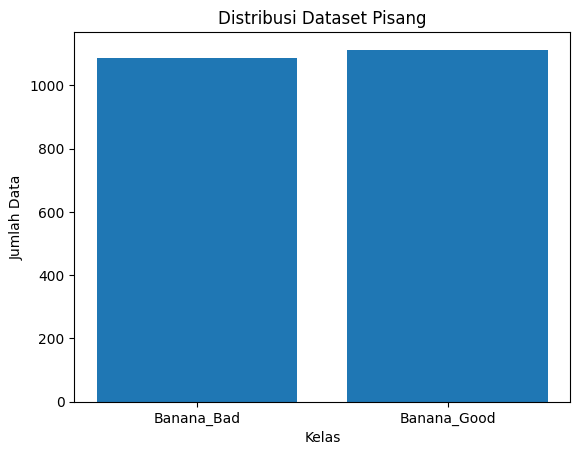

In [ ]:
labels_name = ["Banana_Bad", "Banana_Good"]
counts = [sum(y == 0), sum(y == 1)]

plt.bar(labels_name, counts)
plt.title("Distribusi Dataset Pisang")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.show()

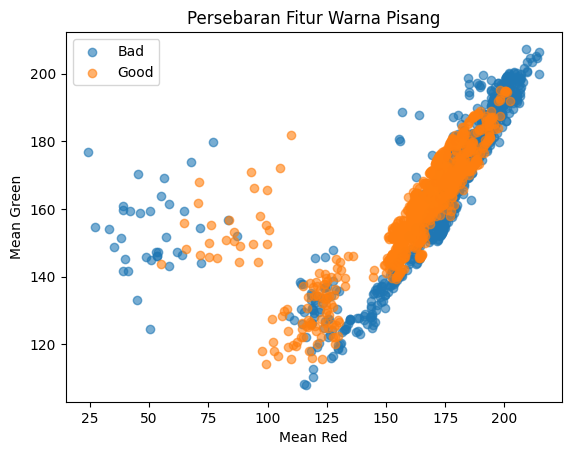

In [ ]:
plt.scatter(X[y==0][:,0], X[y==0][:,1], label="Bad", alpha=0.6)
plt.scatter(X[y==1][:,0], X[y==1][:,1], label="Good", alpha=0.6)

plt.xlabel("Mean Red")
plt.ylabel("Mean Green")
plt.title("Persebaran Fitur Warna Pisang")
plt.legend()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Akurasi Model :", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

Akurasi Model : 0.706060606060606

Confusion Matrix:
 [[209 125]
 [ 69 257]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.63      0.68       334
           1       0.67      0.79      0.73       326

    accuracy                           0.71       660
   macro avg       0.71      0.71      0.70       660
weighted avg       0.71      0.71      0.70       660



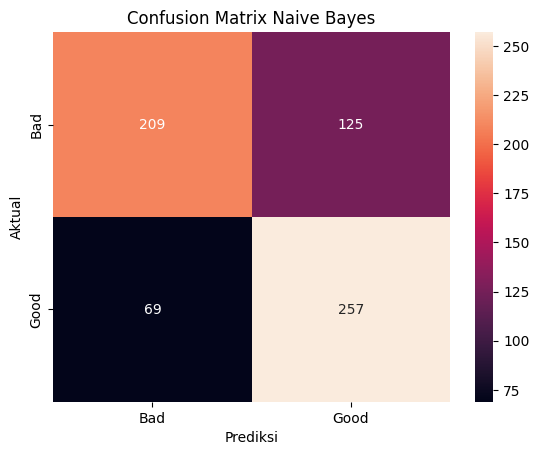

In [ ]:
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Bad", "Good"],
            yticklabels=["Bad", "Good"])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Naive Bayes")
plt.show()

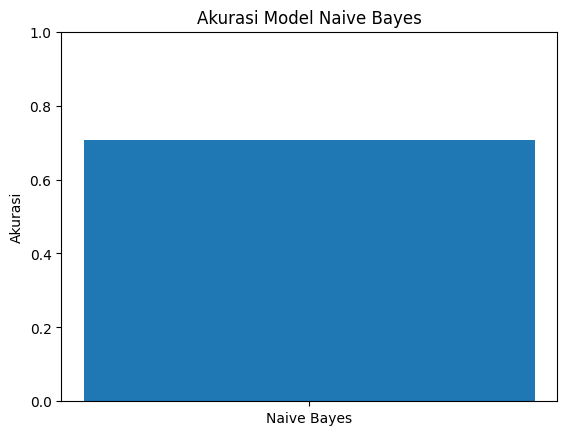

In [ ]:
plt.bar(["Naive Bayes"], [accuracy])
plt.ylim(0,1)
plt.ylabel("Akurasi")
plt.title("Akurasi Model Naive Bayes")
plt.show()

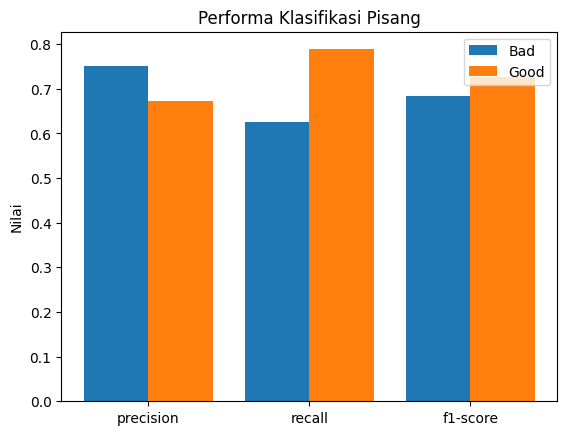

In [ ]:
report_dict = classification_report(y_test, y_pred, output_dict=True)

metrics = ["precision", "recall", "f1-score"]
bad = [report_dict["0"][m] for m in metrics]
good = [report_dict["1"][m] for m in metrics]

x = np.arange(len(metrics))

plt.bar(x - 0.2, bad, 0.4, label="Bad")
plt.bar(x + 0.2, good, 0.4, label="Good")

plt.xticks(x, metrics)
plt.ylabel("Nilai")
plt.title("Performa Klasifikasi Pisang")
plt.legend()
plt.show()

In [ ]:
uploaded = files.upload()

Saving gambar uji coba.jpg to gambar uji coba.jpg


In [ ]:
image_path = list(uploaded.keys())[0]
print("File terupload:", image_path)

File terupload: gambar uji coba.jpg


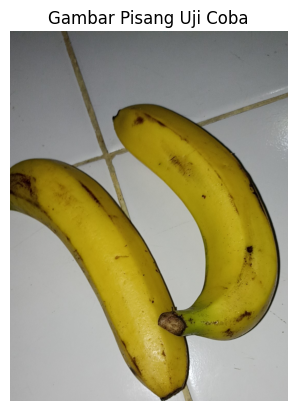

In [ ]:
image = Image.open(image_path)
plt.imshow(image)
plt.axis('off')
plt.title("Gambar Pisang Uji Coba")
plt.show()

In [ ]:
feature_test = extract_features(image_path)

In [ ]:
result = model.predict([feature_test])
prob = model.predict_proba([feature_test])

In [ ]:
if result[0] == 1:
    print("✅ Hasil Prediksi: Pisang Bagus")
else:
    print("❌ Hasil Prediksi: Pisang Tidak Bagus")

print(f"Probabilitas Bagus : {prob[0][1]*100:.2f}%")
print(f"Probabilitas Tidak Bagus  : {prob[0][0]*100:.2f}%")

✅ Hasil Prediksi: Pisang Bagus
Probabilitas Bagus : 88.45%
Probabilitas Tidak Bagus  : 11.55%


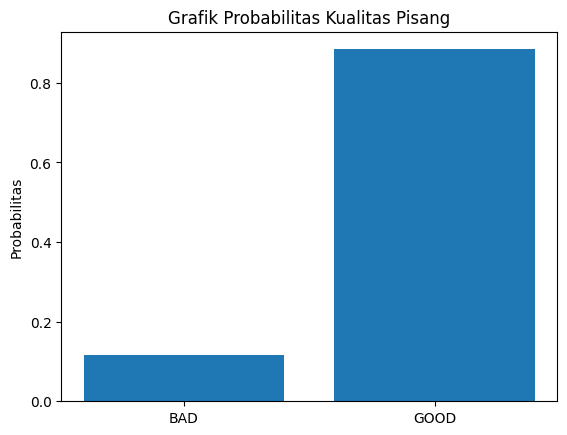

In [ ]:
labels = ['BAD', 'GOOD']
values = prob[0]

plt.figure()
plt.bar(labels, values)
plt.ylabel("Probabilitas")
plt.title("Grafik Probabilitas Kualitas Pisang")
plt.show()